# From a base model to instruction following

Next-token pretraining teaches continuation. Instruction tuning changes the training distribution so the model learns a response format and task behavior. We will make that distinction concrete with a tiny supervised dataset and a masked loss over response tokens.

In [1]:
import math
import random
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.nn import functional as F
SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

Matplotlib is building the font cache; this may take a moment.


device: cpu


In [2]:
examples = [('Question: 2+2\nAnswer:', ' 4'), ('Question: capital of France\nAnswer:', ' Paris'), ('Question: opposite of hot\nAnswer:', ' cold')]
for prompt, response in examples:
    print(repr(prompt), '->', repr(response))

'Question: 2+2\nAnswer:' -> ' 4'
'Question: capital of France\nAnswer:' -> ' Paris'
'Question: opposite of hot\nAnswer:' -> ' cold'


The prompt is context. The response is the sequence whose tokens receive the supervised loss. In a real project the format, data quality, held-out prompts, and regressions must be documented; a few successful examples are not enough.

In [3]:
sequence = ['Question:', ' 2+2', '\nAnswer:', ' 4']
response_start = 3
loss_mask = torch.tensor([0, 0, 0, 1], dtype=torch.bool)
print('tokens:', sequence)
print('loss mask:', loss_mask.tolist())

tokens: ['Question:', ' 2+2', '\nAnswer:', ' 4']
loss mask: [False, False, False, True]


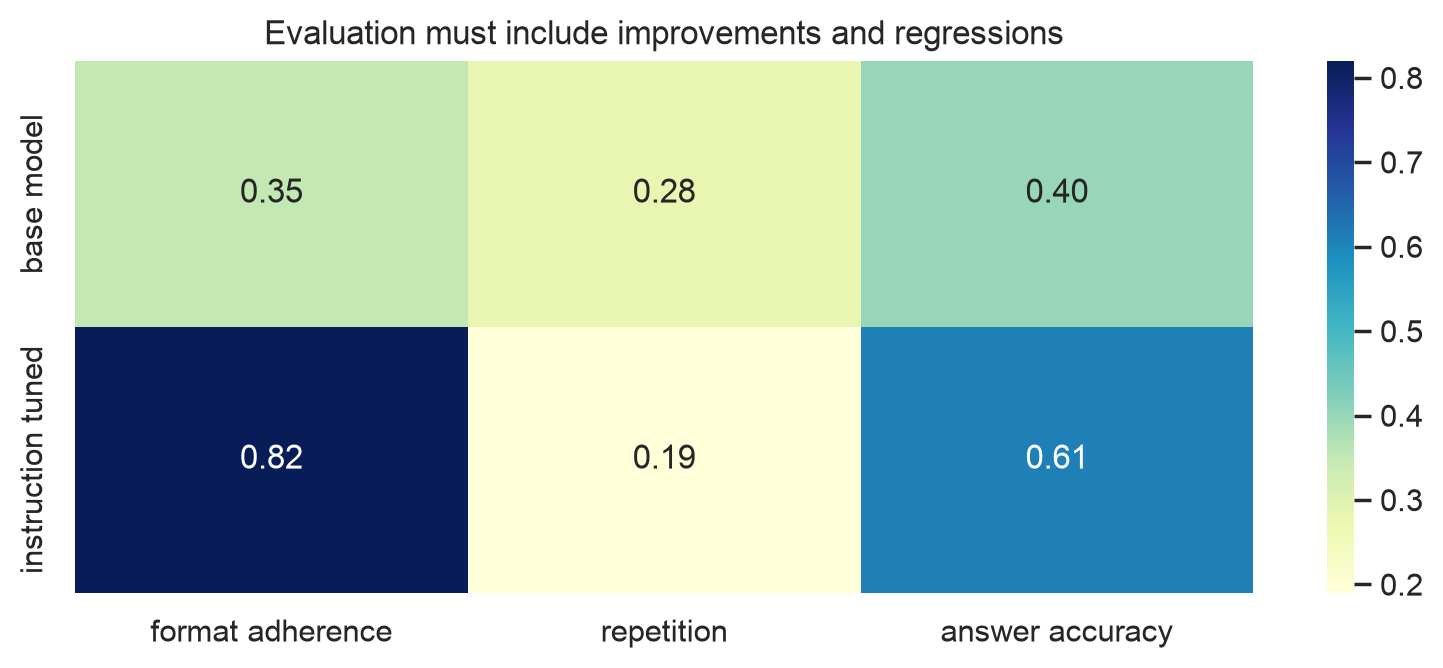

In [4]:
scores = {'base model': {'format adherence': 0.35, 'repetition': 0.28, 'answer accuracy': 0.4}, 'instruction tuned': {'format adherence': 0.82, 'repetition': 0.19, 'answer accuracy': 0.61}}
frame = torch.tensor([[*values.values()] for values in scores.values()])
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(frame, annot=True, fmt='.2f', cmap='YlGnBu', xticklabels=list(next(iter(scores.values())).keys()), yticklabels=scores.keys(), ax=ax)
ax.set_title('Evaluation must include improvements and regressions')
plt.tight_layout()
plt.show()

## Pretraining and instruction tuning solve different problems

Pretraining estimates the distribution of text continuation. Instruction tuning adds examples where a prompt is followed by a response with a desired format and task behavior. The second stage does not create the model’s general language knowledge from nothing; it reshapes how that knowledge is elicited.

## Response-only supervision

In supervised fine-tuning, the prompt is provided as context but the loss is often applied only to response tokens. A mask implements that choice. If prompt tokens contribute equally, the model is rewarded for reproducing the prompt format rather than concentrating its capacity on the answer.

## Held-out behavior and regressions

Instruction tuning can improve adherence while harming breadth, calibration, or repetition. A responsible comparison includes held-out prompts and reports regressions as well as improvements. The small heatmap is a compact reminder that one aggregate score is not enough.

Instruction tuning is supervised adaptation, not a replacement for pretraining. It can improve adherence on the target format while reducing breadth or increasing undesirable shortcuts. The correct next step is a held-out comparison with explicit failure categories.